In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.tile.nearest import Tile2SymbNearest

from tests.experimental.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/Inconsolata-Regular.ttf"
FONT_SIZE = 10
MAX_WIDTH = 30
MAX_HEIGHT = 9
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:10]]


def make_converter(params: Params):
    return Tile2SymbNearest(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        **params.converter_args)

Min: 0.0316 | Max: 0.1841 | Mean: 0.0941 | Std: 0.0406
Min: 0.0304 | Max: 0.2053 | Mean: 0.0971 | Std: 0.0481
Min: 0.0482 | Max: 0.2617 | Mean: 0.1280 | Std: 0.0584
Min: 0.0095 | Max: 0.3070 | Mean: 0.1363 | Std: 0.0787


C:\Users\wojte\AppData\Local\Temp\ipykernel_3576\2314016341.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


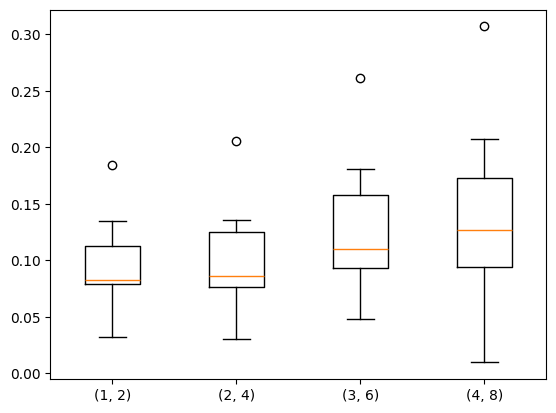

In [2]:
# val_wh

params_space = [
    (w, w * 2) for w in range(1, 5, 1)
]

params_space = list(
    map(lambda val_wh: Params(
        win_width=val_wh[0],
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={'val_wh': val_wh},
        preprocess_args={}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['val_wh'] for param in params_space])
plt.show()

Min: -0.0096 | Max: 0.1657 | Mean: 0.0708 | Std: 0.0489
Min: 0.0259 | Max: 0.2351 | Mean: 0.1135 | Std: 0.0566
Min: 0.0710 | Max: 0.2951 | Mean: 0.1535 | Std: 0.0618
Min: 0.0888 | Max: 0.3034 | Mean: 0.1773 | Std: 0.0607
Min: 0.0983 | Max: 0.3055 | Mean: 0.1863 | Std: 0.0586


C:\Users\wojte\AppData\Local\Temp\ipykernel_3576\2354411618.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


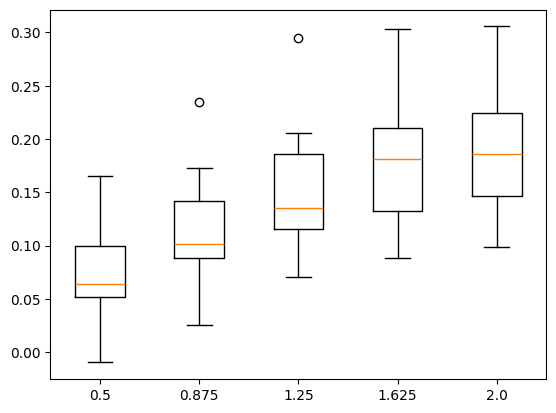

In [3]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        win_width=3,
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

In [4]:
import math
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = Tile2SymbNearest(symbols=SYMBOLS,
                             font=ImageFont.truetype(FONT_PATH, FONT_SIZE))

results = []
for img_path in IMG_PATHS[:5]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    win_w = 3
    win_h = win_w * 2
    if MAX_WIDTH:
        scale_w = MAX_WIDTH * win_w / img.width
    if MAX_HEIGHT:
        scale_h = MAX_HEIGHT * win_h / img.height
    img = preprocess_img(img, scale_factor=min(scale_h, scale_w))
    res_arr = converter.process_image(img, (win_w, win_h))
    results.append(res_arr)

print_gallery(results, 2)

d:\CS Projects\python-playground\python-ascii-art\tests\experimental\grayscale\tile\../../../../src\converters\tile\nearest.py:39: UserWarning: It is recommended to use mode = grid-constant instead of constant when grid_mode is True.
  tile = zoom(tile, zoom_factors, order=0, grid_mode=True)


---------------------------------------------------------------
 | "=99@@@m##ggg==sm@@ssssss-- | f$$@$Q$g$Q{]$@QQQQ$QQ${Q$@$ | 
 | _g_____jj_________          | 9{9t]Q@QQQt~R%$$$QQ@Q&@@@E" | 
 | QQQQQQQQQQQQQQQQQQQQQQQQQQQ | ~`{jj@QgQQQ~t`"98@Q_{j~{_s{ | 
 | QQQQQQQQ$$QQQQQQQQQQQQQQQQQ | jggQQQQQ[`"f"   `{Q@{@QQQ{{ | 
 | QQQQQQ$``~~~]$QQQQQQQQQQQQ$ | Q@@Q8QQg$&g      Q88QQQQ@Q{ | 
 | QQQQQ$ggj$jg]QQQQQQQggQQQQQ | 9QgggQQQQQQr    ]8Q@QQQ{8{{ | 
 | QQQQQQQQQQQQQQQQQQQQQQQQQQQ | j@QQQQQQQQQ[    ]gQQQ@@Qg8{ | 
 | QQQQQQQQQQQ$QQQ$QQQQQQQQQQ{ | jQ88QQQQQQQ[   jf"""QQ@Q@@t | 
 | QQ$QQ$QQ$$QQQQQQQQQQQQQQQQt | Q88Qf@Q@$gQ[`.3@g~  ~?9Q@Q{ | 
---------------------------------------------------------------
 | @@@8&8f`~~`sjgggm{sgQ@$f`-  |              | 
 | ss{{{)~~~)ss{8{""``"`~-  ~` | ____________ | 
 | {{{{{{{{{j)){jgg)~sssss{~j; | QQQQQQQQQQQQ | 
 | {{{9@[[QQQQ@$$$Q$ggjgQ$Q$$[ | QQQQ88@@QQQQ | 
 | {{{@{f9@@Q8{9QQ8Q@@@@f"]@@t | QQQQ#]["QQQQ | 
 | 9999{{t   ^{9{9999f{f){`"   | QQQQ[   ]QQQ | 
 |